In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [25]:
# read the file: C:\Users\Sepehr\Desktop\LLM-RL\create_figures\outputs\agent_intervention_matrix_20_20_10_0.25.npy
agent_intervention_matrix = np.load('../environment_simplified/outputs/last_action/agent_intervention_matrix_20_20_10_0.25.npy')
agent_intervention_matrix.shape

(10, 20, 20, 20, 2)

In [26]:
for i in range(10):
    for j in range(20):
        for k in range(20):
            for l in range(20):
                pair = agent_intervention_matrix[i, j, k, l]
                # drop nan values
                if np.isnan(pair).any():
                    continue
                if pair[0] == 1 or pair[1] == 1:
                    # print in which round, time and which pair of agents are intervened
                    print(i, j, k, l, pair)


In [27]:
# get the number of [0, 0], [0, 2], [2, 0], [2, 2] pairs in each round and each time step (first two dimentions)
all_data = {}
for i in range(10):
    for j in range(20):
        intervention_00 = int(np.sum(agent_intervention_matrix[i, j] == [0, 0]))
        intervention_02_20 = int(np.sum(agent_intervention_matrix[i, j] == [0, 2]) + np.sum(agent_intervention_matrix[i, j] == [2, 0]))
        intervention_22 = int(np.sum(agent_intervention_matrix[i, j] == [2, 2]))
        total_interventions = intervention_00 + intervention_02_20 + intervention_22
        if total_interventions == 0:
            continue
        # this prints round number, step number, and the number of [0, 0], [0, 2] or [2, 0], [2, 2] pairs in each round and each time step
        print(i, j, intervention_00, intervention_02_20, intervention_22)
        all_data[(i, j)] = [round(intervention_00/total_interventions, 2), round(intervention_02_20/total_interventions, 2), round(intervention_22/total_interventions, 2)]
        # print the sum of all pairs in each round and each time step
    print(intervention_00 + intervention_02_20 + intervention_22)
all_data

0 0 204 204 0
0 1 204 204 0
0 2 204 204 0
0 3 204 204 0
0 4 204 204 0
0 5 204 204 0
0 6 204 204 0
0 7 204 204 0
0 8 204 204 0
0 9 204 204 0
0 10 204 204 0
0 11 204 204 0
0 12 204 204 0
0 13 204 204 0
0 14 204 204 0
0 15 204 204 0
0 16 204 204 0
0 17 204 204 0
0 18 204 204 0
0 19 204 204 0
408
1 0 216 216 0
1 1 216 216 0
1 2 216 216 0
1 3 216 216 0
1 4 216 216 0
1 5 216 216 0
1 6 216 216 0
1 7 216 216 0
1 8 216 216 0
1 9 216 216 0
1 10 216 216 0
1 11 216 216 0
1 12 216 216 0
1 13 216 216 0
1 14 216 216 0
1 15 216 216 0
1 16 216 216 0
1 17 216 216 0
1 18 216 216 0
1 19 216 216 0
432
2 0 196 196 0
2 1 196 196 0
2 2 196 196 0
2 3 196 196 0
2 4 196 196 0
2 5 196 196 0
2 6 196 196 0
2 7 196 196 0
2 8 196 196 0
2 9 196 196 0
2 10 196 196 0
2 11 196 196 0
2 12 196 196 0
2 13 196 196 0
2 14 196 196 0
2 15 196 196 0
2 16 196 196 0
2 17 196 196 0
2 18 196 196 0
2 19 196 196 0
392
3 0 236 236 0
3 1 236 236 0
3 2 236 236 0
3 3 236 236 0
3 4 236 236 0
3 5 236 236 0
3 6 236 236 0
3 7 236 236 0
3 8 23

{(0, 0): [0.5, 0.5, 0.0],
 (0, 1): [0.5, 0.5, 0.0],
 (0, 2): [0.5, 0.5, 0.0],
 (0, 3): [0.5, 0.5, 0.0],
 (0, 4): [0.5, 0.5, 0.0],
 (0, 5): [0.5, 0.5, 0.0],
 (0, 6): [0.5, 0.5, 0.0],
 (0, 7): [0.5, 0.5, 0.0],
 (0, 8): [0.5, 0.5, 0.0],
 (0, 9): [0.5, 0.5, 0.0],
 (0, 10): [0.5, 0.5, 0.0],
 (0, 11): [0.5, 0.5, 0.0],
 (0, 12): [0.5, 0.5, 0.0],
 (0, 13): [0.5, 0.5, 0.0],
 (0, 14): [0.5, 0.5, 0.0],
 (0, 15): [0.5, 0.5, 0.0],
 (0, 16): [0.5, 0.5, 0.0],
 (0, 17): [0.5, 0.5, 0.0],
 (0, 18): [0.5, 0.5, 0.0],
 (0, 19): [0.5, 0.5, 0.0],
 (1, 0): [0.5, 0.5, 0.0],
 (1, 1): [0.5, 0.5, 0.0],
 (1, 2): [0.5, 0.5, 0.0],
 (1, 3): [0.5, 0.5, 0.0],
 (1, 4): [0.5, 0.5, 0.0],
 (1, 5): [0.5, 0.5, 0.0],
 (1, 6): [0.5, 0.5, 0.0],
 (1, 7): [0.5, 0.5, 0.0],
 (1, 8): [0.5, 0.5, 0.0],
 (1, 9): [0.5, 0.5, 0.0],
 (1, 10): [0.5, 0.5, 0.0],
 (1, 11): [0.5, 0.5, 0.0],
 (1, 12): [0.5, 0.5, 0.0],
 (1, 13): [0.5, 0.5, 0.0],
 (1, 14): [0.5, 0.5, 0.0],
 (1, 15): [0.5, 0.5, 0.0],
 (1, 16): [0.5, 0.5, 0.0],
 (1, 17): [0.5, 0.5, 

In [28]:
# show all data values with a key like (0, any)
for key, value in all_data.items():
    if key[1] == 5:
        print(key, value)

(0, 5) [0.5, 0.5, 0.0]
(1, 5) [0.5, 0.5, 0.0]
(2, 5) [0.5, 0.5, 0.0]
(3, 5) [0.5, 0.5, 0.0]
(4, 5) [0.5, 0.5, 0.0]
(5, 5) [0.5, 0.5, 0.0]
(6, 5) [0.5, 0.5, 0.0]
(7, 5) [0.5, 0.5, 0.0]
(8, 5) [0.5, 0.5, 0.0]
(9, 5) [0.5, 0.5, 0.0]


In [29]:
# now average the data over the first element of the tuple
average_data = {}
for key, value in all_data.items():
    if key[1] not in average_data:
        average_data[key[1]] = np.array(value)
    else:
        average_data[key[1]] += np.array(value)
for key in average_data:
    print(average_data[key])
    average_data[key] /= 10

# make the values of the dictionary a list
average_data = {key: value.tolist() for key, value in average_data.items()}
# round the values of the dictionary to 2 decimal points
average_data = {key: [round(value, 2) for value in value] for key, value in average_data.items()}
average_data

# add two more key, values to the data
# 0: [0, 0, 0]
# 1: [0, 0, 0]


[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]
[5. 5. 0.]


{0: [0.5, 0.5, 0.0],
 1: [0.5, 0.5, 0.0],
 2: [0.5, 0.5, 0.0],
 3: [0.5, 0.5, 0.0],
 4: [0.5, 0.5, 0.0],
 5: [0.5, 0.5, 0.0],
 6: [0.5, 0.5, 0.0],
 7: [0.5, 0.5, 0.0],
 8: [0.5, 0.5, 0.0],
 9: [0.5, 0.5, 0.0],
 10: [0.5, 0.5, 0.0],
 11: [0.5, 0.5, 0.0],
 12: [0.5, 0.5, 0.0],
 13: [0.5, 0.5, 0.0],
 14: [0.5, 0.5, 0.0],
 15: [0.5, 0.5, 0.0],
 16: [0.5, 0.5, 0.0],
 17: [0.5, 0.5, 0.0],
 18: [0.5, 0.5, 0.0],
 19: [0.5, 0.5, 0.0]}

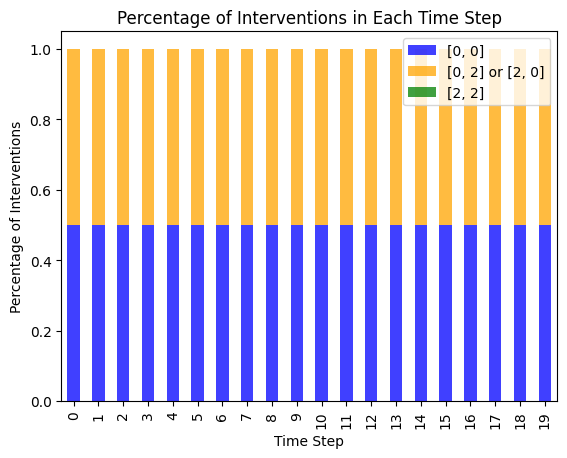

In [30]:
# draw a stacked bar plot
df = pd.DataFrame(average_data)
df = df.T
df.columns = ['[0, 0]', '[0, 2] or [2, 0]', '[2, 2]']
df.plot(kind='bar', stacked=True, color=['blue', 'orange', 'green'], alpha=0.75)
plt.xlabel('Time Step')
plt.ylabel('Percentage of Interventions')
plt.title('Percentage of Interventions in Each Time Step')
plt.show()